## Задача "пенальти"
На тренировочной базе установлен прямоугольный защитный экран, ширина которого составляет 14,64 метра, а высота 4,88 метра. Вдоль нижней границы этого экрана, ровно посередине, нарисованы стандартные футбольные ворота шириной 7,32 метра и высотой 2,44 метра. Футболист бьёт по мячу, и тот попадает в случайную точку защитного экрана.
1. Найдите теоретическую вероятность попадания мяча в створ ворот.
2. Смоделируйте процесс удара по мячу. Сравните экспериментальный результат с теоретическим и постройте графическую иллюстрацию.

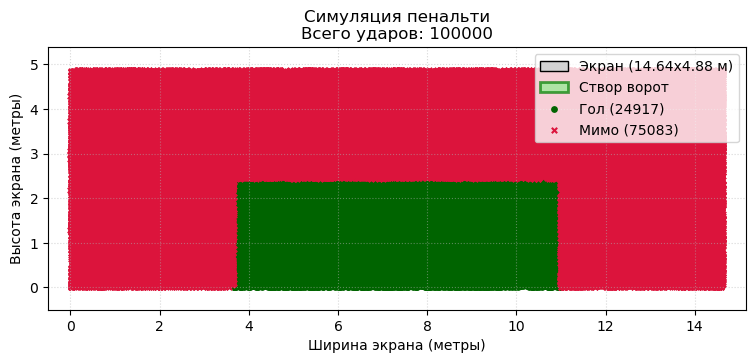

Всего нанесено ударов: 100000
Мячей в сетке ворот: 24917
Экспериментальная вероятность: 0.24917
Теоретическая вероятность: 0.25


In [7]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import numpy as np

def football_simulation_proportional(kicks):
    # Реальные размеры ворот
    goalw = 7.32
    goalh = 2.44
    
    # Размеры экрана
    wallw = 14.64
    wallh = 4.88
    
    # Координаты ворот
    goal_x_min = (wallw - goalw) / 2 
    goal_x_max = goal_x_min + goalw
    goal_y_min = 0.0
    goal_y_max = goalh
    
    s_wall = wallw * wallh
    s_goal = goalw * goalh
    theor_p = s_goal / s_wall
    
    # Моделируем случайные удары
    X = np.random.uniform(0, wallw, kicks)
    Y = np.random.uniform(0, wallh, kicks)
    
    # Условие попадания в ворота
    is_goal = (X >= goal_x_min) & (X <= goal_x_max) & (Y >= goal_y_min) & (Y <= goal_y_max)
    goals_count = np.sum(is_goal)
    
    # Экспериментальная вероятность
    experim_p = goals_count / kicks
    
    # График
    fig, ax = plt.subplots(figsize=(9, 4))
    ax.set_xlim(-0.5, wallw + 0.5)
    ax.set_ylim(-0.5, wallh + 0.5)
    
    ax.add_patch(Rectangle((0, 0), wallw, wallh, facecolor='lightgray', edgecolor='black', label=f'Экран ({wallw}х{wallh} м)'))
    ax.add_patch(Rectangle((goal_x_min, goal_y_min), goalw, goalh, facecolor='lightgreen', alpha=0.7, edgecolor='green', lw=2, label='Створ ворот'))
    
    ax.scatter(X[is_goal], Y[is_goal], marker='o', c='darkgreen', s=15, label=f'Гол ({goals_count})')
    ax.scatter(X[~is_goal], Y[~is_goal], marker='x', c='crimson', s=15, label=f'Мимо ({kicks - goals_count})')
    
    ax.set_aspect('equal')
    ax.set_xlabel('Ширина экрана (метры)')
    ax.set_ylabel('Высота экрана (метры)')
    ax.legend(loc='upper right')
    plt.title(f'Симуляция пенальти\nВсего ударов: {kicks}')
    plt.grid(True, linestyle=':', alpha=0.5)
    plt.show()
    
    print(f"Всего нанесено ударов: {kicks}")
    print(f"Мячей в сетке ворот: {goals_count}")
    print(f"Экспериментальная вероятность: {experim_p}")
    print(f"Теоретическая вероятность: {theor_p}")

football_simulation_proportional(100000)
